In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os

import cartopy.crs as ccrs
import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import metpy  # noqa: F401
import numpy as np
import xarray as xr
import yaml
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec
from unseen_awg.plotting_utils import (
    add_contours,
    add_label_to_axes,
    contourf_plot_without_frame_with_bounds,
)
from unseen_awg.weather_generator import WeatherGenerator

In [12]:
ALPHABET = "abcdefghijklmnop"

In [13]:
mpl.rc_file("../../matplotlibrc")

In [14]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [15]:
wg_era5 = WeatherGenerator.load(
    os.path.join(paths["dir_wgs"], "wg_era5_f3d1f2f7_6e629cd9_7560715e")
)
wg_reforecasts = WeatherGenerator.load(
    os.path.join(paths["dir_wgs"], "wg_reforecasts_5e06172f_f40e9460_1e69bda9")
)

In [16]:
state_re = xr.Dataset(
    {"year": 2023, "dayofyear": 248, "sample": 13, "ensemble_member": 0}
)
state_era = xr.Dataset(
    {"year": 2023, "dayofyear": 248, "sample": 0, "ensemble_member": 0}
)

In [17]:
k = 2
minimum_timedelta_days = 180

vmin = 500
vmax = 610
minor_spacing_contours = 10
major_spacing_contours = 30

# preps for contour plots
major_levels = np.arange(vmin, vmax, major_spacing_contours)
minor_levels = np.arange(vmin, vmax, minor_spacing_contours)
minor_levels = minor_levels[~np.isin(minor_levels, major_levels)]

In [18]:
similarities_era = wg_era5.get_similarities_k_closest_neighbors(
    states=state_era, k=k, minimum_timedelta_days=minimum_timedelta_days
)

da_era = wg_era5.get_analog_data(similarities_era, use_candidate_coords=True)
da_base = wg_era5.get_analog_data(
    similarities_era, use_candidate_coords=False
).metpy.quantify()

In [19]:
similarities_re = wg_reforecasts.get_similarities_k_closest_neighbors(
    states=state_re, k=k, minimum_timedelta_days=minimum_timedelta_days
)
da_re = wg_reforecasts.get_analog_data(similarities_re, use_candidate_coords=True)

In [20]:
coords_leipzig = {"latitude": 51.340199, "longitude": 12.360103}

t2m_clim_max = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_ref_max.nc")
)
t2m_clim_mean = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_ref_mean.nc")
)
t2m_clim_median = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_ref_median.nc")
)
t2m_clim_min = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_ref_min.nc")
)

clim_era5_max = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_era_slice_max.nc")
)
clim_era5_mean = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_era_slice_mean.nc")
)
clim_era5_median = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_era_slice_median.nc")
)
clim_era5_min = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max/clim_era_slice_min.nc")
)

In [21]:
def get_n_random_base_samples(wg: WeatherGenerator, n_samples, lead_time=None):
    da = wg.ds_similarities.lead_time.load()

    flat_da = da.stack(sdim=da.dims)
    flat_da = flat_da.where(~np.isnan(flat_da), drop=True)

    if lead_time is not None:
        flat_da = flat_da.where(flat_da == lead_time, drop=True)

    random_subset = np.random.choice(
        np.arange(len(flat_da)), size=n_samples, replace=False
    )
    pseudo_ensemble_member_data = np.random.choice(
        wg.ds_similarities.ensemble_member, size=n_samples, replace=True
    )
    return flat_da.isel(sdim=random_subset).assign_coords(
        {"ensemble_member": ("sdim", pseudo_ensemble_member_data)}
    )

In [ ]:
n_samples = 500
minimum_timedelta_days = 180

base_samples_re = get_n_random_base_samples(wg=wg_reforecasts, n_samples=n_samples)
base_samples_era = get_n_random_base_samples(wg=wg_era5, n_samples=n_samples)

sims_neighbors_re = np.sqrt(
    -wg_reforecasts.get_similarities_k_closest_neighbors(
        states=base_samples_re,
        k=k,
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)
sims_neighbors_era = np.sqrt(
    -wg_era5.get_similarities_k_closest_neighbors(
        states=base_samples_era,
        k=k,
        dim_states="sdim",
        minimum_timedelta_days=minimum_timedelta_days,
    )
)

In [23]:
all_levels = np.sort(np.concatenate((minor_levels, major_levels)))

cmap = plt.get_cmap("cmc.imola", len(all_levels))

cmap = ListedColormap(cmap(np.linspace(0, 1, len(all_levels))))

norm = BoundaryNorm(all_levels, cmap.N)

<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1291629/803562204.py:110: SyntaxWarning: invalid escape sequence '\m'
  r"$t_\mathrm{init}$"


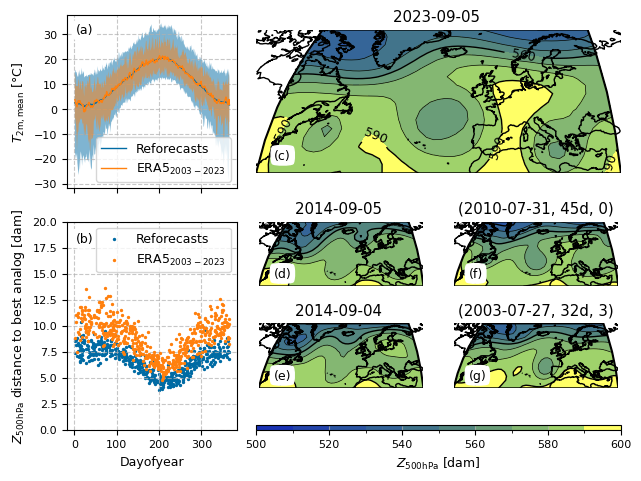

In [24]:
fig = plt.figure()

gs = GridSpec(
    k + 2,
    3,
    figure=fig,
    height_ratios=[2]
    + [
        0.75,
    ]
    * k
    + [
        0.05,
    ],
    width_ratios=[1, 1, 1],
)

font_kwargs = dict(fontweight="bold", fontsize="large")

ax_cbar = fig.add_subplot(gs[-1, 1:])

# title_overall = fig.add_subplot(gs[0, 1:])

# title_era = fig.add_subplot(gs[2, 1])
# title_re = fig.add_subplot(gs[2, 2])
# title_era.text(
#     x=0.5, y=0.5, s="ERA5 (2003-2023)", horizontalalignment="center", **font_kwargs
# )
# title_re.text(
#     x=0.5, y=0.5, s="Reforecasts", horizontalalignment="center", **font_kwargs
# )
# title_overall.text(
#     x=0.5, y=0.5, s="Base state", horizontalalignment="center", **font_kwargs
# )
# title_era.axis("off")
# title_re.axis("off")
# title_overall.axis("off")

# actual plotting
# base state:
ax_base = fig.add_subplot(gs[0, 1:3], projection=ccrs.Robinson())
contourf_plot_without_frame_with_bounds(
    ax=ax_base,
    da=da_base.squeeze(),
    levels=all_levels,
    cmap=cmap,
    norm=norm,
    cbar_ax=ax_cbar,
    cbar_kwargs={"orientation": "horizontal", "label": r"$Z_\mathrm{500hPa}$ [dam]"},
)
add_contours(
    ax=ax_base,
    da=da_base,
    major_levels=major_levels,
    minor_levels=minor_levels,
    add_labels=True,
)
ax_base.set_title(
    f"{np.datetime_as_string((da_base.init_time + da_base.lead_time).squeeze(), unit='D')} "
)

add_label_to_axes(ax=ax_base, label="(c)", va="bottom", ax_ypos=0.08, ax_xpos=0.05)

ax_base.set_rasterized(True)


for i in range(k):
    # nearest neigbors:
    ax_era = fig.add_subplot(gs[1 + i, 1], projection=ccrs.Robinson())
    da_nb = da_era.isel(neighbor=i)
    contourf_plot_without_frame_with_bounds(
        ax=ax_era,
        da=da_nb.squeeze(),
        levels=all_levels,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    add_contours(
        ax=ax_era,
        da=da_nb,
        major_levels=major_levels,
        minor_levels=minor_levels,
        use_contour_labels=False,
    )
    ax_era.set_title(
        f"{np.datetime_as_string((da_nb.c_init_time + da_nb.c_lead_time).squeeze(), unit='D')} "
    )

    # random neighbor:
    ax_re = fig.add_subplot(gs[1 + i, 2], projection=ccrs.Robinson())
    da_nb = da_re.isel(neighbor=i)
    contourf_plot_without_frame_with_bounds(
        ax=ax_re,
        da=da_nb.squeeze(),
        levels=all_levels,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    add_contours(
        ax=ax_re,
        da=da_nb,
        major_levels=major_levels,
        minor_levels=minor_levels,
        use_contour_labels=False,
    )
    """
    ax_re.set_title(
        r"$t_\mathrm{init}$"
        + f": {np.datetime_as_string((da_nb.c_init_time).squeeze(), unit='D')} "
        + r"$t_\mathrm{lead}$"
        + f": {int((da_nb.c_lead_time / np.timedelta64(1, 'D')).data)}d "
        + "$m$"
        + f": {da_nb.c_sample.data} "
    )
    """

    ax_re.set_title(
        f"({np.datetime_as_string((da_nb.c_init_time).squeeze(), unit='D')}, {int((da_nb.c_lead_time / np.timedelta64(1, 'D')).data)}d, {da_nb.c_sample.data})"
    )

    ax_re.set_rasterized(True)
    ax_era.set_rasterized(True)

    add_label_to_axes(
        ax=ax_re,
        label=f"({ALPHABET[3 + i + k]})",
        va="bottom",
        ax_ypos=0.1,
        ax_xpos=0.09,
    )
    add_label_to_axes(
        ax=ax_era, label=f"({ALPHABET[3 + i]})", va="bottom", ax_ypos=0.1, ax_xpos=0.09
    )

ax_clim = fig.add_subplot(gs[0, 0])

t2m_clim_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
    ax=ax_clim, color="C0", label="Reforecasts", linewidth=1, zorder=3
)
ax_clim.fill_between(
    t2m_clim_mean["t2m"].dayofyear,
    t2m_clim_min["t2m"].sel(coords_leipzig, method="nearest"),
    t2m_clim_max["t2m"].sel(coords_leipzig, method="nearest"),
    alpha=0.5,
    color="C0",
    edgecolor="none",
    zorder=1,
)

clim_era5_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
    ax=ax_clim, color="C1", label=r"$\text{ERA5}_{2003-2023}$", linewidth=1, zorder=4
)
ax_clim.fill_between(
    clim_era5_min["t2m"].dayofyear,
    clim_era5_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    clim_era5_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    alpha=0.5,
    color="C1",
    edgecolor="none",
    zorder=2,
)
# ax_clim.set_title(r"Min/max/mean $T_{2m}$, Leipzig")
ax_clim.set_title("")
ax_clim.set_ylabel(r"$T_\mathrm{2m, mean}$ [°C]")
ax_clim.set_xlabel("")
ax_clim.set_xticklabels([])

ax_clim.legend()

add_label_to_axes(ax=ax_clim, label="(a)", va="top", ax_ypos=0.95, ax_xpos=0.05)

ax_nb_dist = fig.add_subplot(gs[1:, 0])

ax_nb_dist.scatter(
    sims_neighbors_re.sel(neighbor=0).dayofyear,
    sims_neighbors_re.sel(neighbor=0),
    label=r"Reforecasts",
    s=2,
    zorder=1,
)
ax_nb_dist.scatter(
    sims_neighbors_era.sel(neighbor=0).dayofyear,
    sims_neighbors_era.sel(neighbor=0),
    label=r"$\text{ERA5}_{2003-2023}$",
    s=2,
    zorder=2,
)
ax_nb_dist.set_ylim(0, 20)
ax_nb_dist.set_xlabel("Dayofyear")
ax_nb_dist.set_ylabel(r"$Z_\mathrm{500hPa}$ distance to best analog [dam]")
# ax_nb_dist.set_title("Distances to nearest neighbor")
ax_nb_dist.legend()

add_label_to_axes(ax=ax_nb_dist, label="(b)", va="top", ax_ypos=0.95, ax_xpos=0.05)


plt.savefig(os.path.join(paths["dir_images"], "advantages_analogs.pdf"), dpi=300)

only base state:

In [25]:
# Create custom colormap from white to #5C9BAF
colors = ["#5C9BAF", "white"]
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "white_to_blue", colors, N=len(all_levels)
)

# Apply to your existing code
all_levels = np.sort(np.concatenate((minor_levels, major_levels)))
cmap = ListedColormap(custom_cmap(np.linspace(0, 1, len(all_levels))))
norm = BoundaryNorm(all_levels, cmap.N)

In [ ]:
fig = plt.figure(figsize=(6, 4))
gs = GridSpec(1, 1)

font_kwargs = dict(fontweight="bold", fontsize="large")

ax_base = fig.add_subplot(gs[0, 0], projection=ccrs.Robinson())
contourf_plot_without_frame_with_bounds(
    ax=ax_base,
    da=da_base.squeeze(),
    levels=all_levels,
    cmap=cmap,
    norm=norm,
    cbar_ax=ax_cbar,
    cbar_kwargs={"orientation": "horizontal", "label": "geopotential height [dam]"},
)
add_contours(
    ax=ax_base,
    da=da_base,
    major_levels=major_levels,
    minor_levels=minor_levels,
    use_contour_labels=False,
)
ax_base.set_title("")
plt.savefig(os.path.join(paths["dir_images"], "single_base_state.png"))

In [27]:
all_levels = np.sort(np.concatenate((minor_levels, major_levels)))

cmap = plt.get_cmap("cmc.imola", len(all_levels))

cmap = ListedColormap(cmap(np.linspace(0, 1, len(all_levels))))

norm = BoundaryNorm(all_levels, cmap.N)

only neighbor panels:

/tmp/ipykernel_1291629/752962795.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


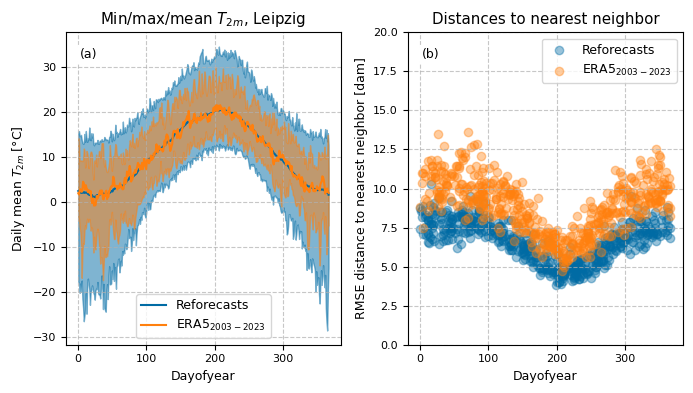

In [28]:
fig = plt.figure(figsize=(7, 4))
gs = GridSpec(1, 2)

font_kwargs = dict(fontweight="bold", fontsize="large")


ax_clim = fig.add_subplot(gs[0])

t2m_clim_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
    ax=ax_clim, color="C0", label="Reforecasts"
)
ax_clim.fill_between(
    t2m_clim_mean["t2m"].dayofyear,
    t2m_clim_min["t2m"].sel(coords_leipzig, method="nearest"),
    t2m_clim_max["t2m"].sel(coords_leipzig, method="nearest"),
    alpha=0.5,
    color="C0",
)

clim_era5_median["t2m"].sel(coords_leipzig, method="nearest").plot(
    ax=ax_clim, color="C1", label=r"$\text{ERA5}_{2003-2023}$"
)
ax_clim.fill_between(
    clim_era5_min["t2m"].dayofyear,
    clim_era5_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    clim_era5_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    alpha=0.5,
    color="C1",
)
ax_clim.set_title(r"Min/max/mean $T_{2m}$, Leipzig")
ax_clim.set_ylabel(r"Daily mean $T_{2m}$ [°C]")
# ax_clim.set_xlabel("")
# ax_clim.set_xticklabels([])
ax_clim.set_xlabel("Dayofyear")
ax_clim.legend()

add_label_to_axes(ax=ax_clim, label="(a)")

ax_nb_dist = fig.add_subplot(gs[1])

ax_nb_dist.scatter(
    sims_neighbors_re.sel(neighbor=0).dayofyear,
    sims_neighbors_re.sel(neighbor=0),
    label=r"Reforecasts",
    alpha=0.4,
)
ax_nb_dist.scatter(
    sims_neighbors_era.sel(neighbor=0).dayofyear,
    sims_neighbors_era.sel(neighbor=0),
    label=r"$\text{ERA5}_{2003-2023}$",
    alpha=0.4,
)
ax_nb_dist.set_ylim(0, 20)
ax_nb_dist.set_xlabel("Dayofyear")
ax_nb_dist.set_ylabel("RMSE distance to nearest neighbor [dam]")
ax_nb_dist.set_title("Distances to nearest neighbor")
ax_nb_dist.legend()

add_label_to_axes(ax=ax_nb_dist, label="(b)")

plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "advantages_neighbors.png"))

/tmp/ipykernel_1291629/1098968116.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


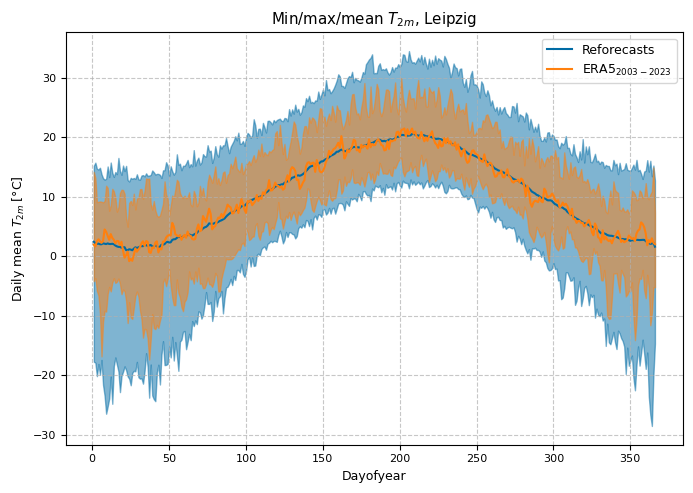

In [29]:
fig = plt.figure(figsize=(7, 5))

font_kwargs = dict(fontweight="bold", fontsize="large")


ax_clim = fig.add_subplot()

t2m_clim_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
    ax=ax_clim, color="C0", label="Reforecasts"
)
ax_clim.fill_between(
    t2m_clim_mean["t2m"].dayofyear,
    t2m_clim_min["t2m"].sel(coords_leipzig, method="nearest"),
    t2m_clim_max["t2m"].sel(coords_leipzig, method="nearest"),
    alpha=0.5,
    color="C0",
)

clim_era5_median["t2m"].sel(coords_leipzig, method="nearest").plot(
    ax=ax_clim, color="C1", label=r"$\text{ERA5}_{2003-2023}$"
)
ax_clim.fill_between(
    clim_era5_min["t2m"].dayofyear,
    clim_era5_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    clim_era5_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    alpha=0.5,
    color="C1",
)
ax_clim.set_title(r"Min/max/mean $T_{2m}$, Leipzig")
ax_clim.set_ylabel(r"Daily mean $T_{2m}$ [°C]")
# ax_clim.set_xlabel("")
# ax_clim.set_xticklabels([])
ax_clim.set_xlabel("Dayofyear")
ax_clim.legend()


plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "advantages_clim.png"))

# repeat with more neighbors

In [30]:
k = 5
minimum_timedelta_days = 180

vmin = 500
vmax = 610
minor_spacing_contours = 10
major_spacing_contours = 30

# preps for contour plots
major_levels = np.arange(vmin, vmax, major_spacing_contours)
minor_levels = np.arange(vmin, vmax, minor_spacing_contours)
minor_levels = minor_levels[~np.isin(minor_levels, major_levels)]

In [31]:
similarities_re = wg_reforecasts.get_similarities_k_closest_neighbors(
    states=state_re, k=k, minimum_timedelta_days=minimum_timedelta_days
)
similarities_era = wg_era5.get_similarities_k_closest_neighbors(
    states=state_era, k=k, minimum_timedelta_days=minimum_timedelta_days
)

da_re = wg_reforecasts.get_analog_data(similarities_re, use_candidate_coords=True)
da_era = wg_era5.get_analog_data(similarities_era, use_candidate_coords=True)
da_base = wg_era5.get_analog_data(
    similarities_era, use_candidate_coords=False
).metpy.quantify()

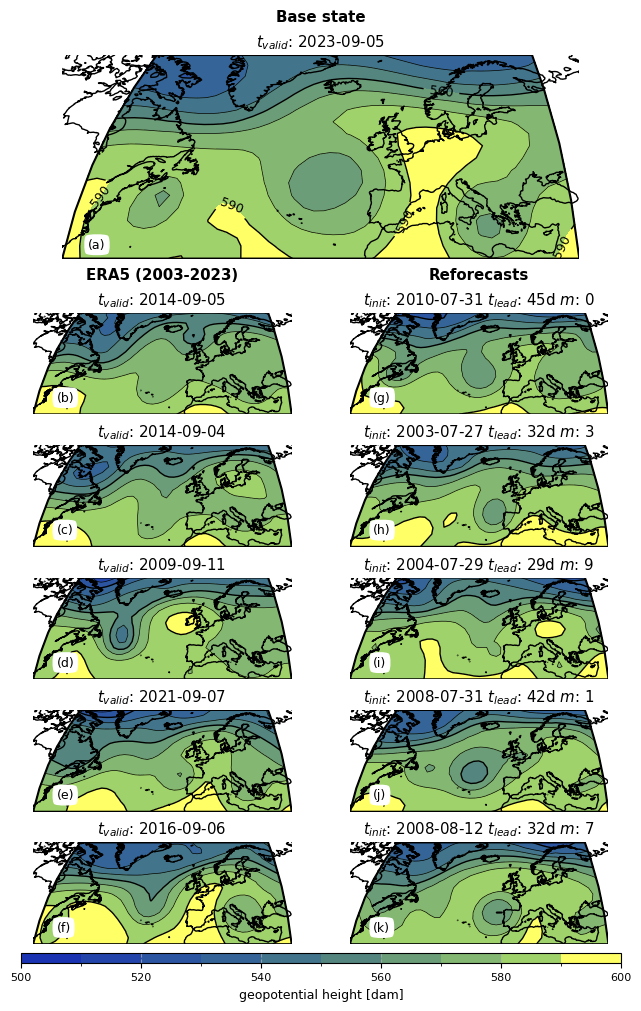

In [32]:
fig = plt.figure()
gs = GridSpec(
    k + 4,
    2,
    figure=fig,
    height_ratios=[0.05, 2, 0.05]
    + [
        1,
    ]
    * k
    + [
        0.1,
    ],
    width_ratios=[1, 1],
)

fig.set_figheight(10)

font_kwargs = dict(fontweight="bold", fontsize="large")

ax_cbar = fig.add_subplot(gs[-1, :])

title_overall = fig.add_subplot(gs[0, :])

title_era = fig.add_subplot(gs[2, 0])
title_re = fig.add_subplot(gs[2, 1])
title_era.text(
    x=0.5, y=0.5, s="ERA5 (2003-2023)", horizontalalignment="center", **font_kwargs
)
title_re.text(
    x=0.5, y=0.5, s="Reforecasts", horizontalalignment="center", **font_kwargs
)
title_overall.text(
    x=0.5, y=0.5, s="Base state", horizontalalignment="center", **font_kwargs
)
title_era.axis("off")
title_re.axis("off")
title_overall.axis("off")

# actual plotting
# base state:
ax_base = fig.add_subplot(gs[1, :], projection=ccrs.Robinson())
contourf_plot_without_frame_with_bounds(
    ax=ax_base,
    da=da_base.squeeze(),
    levels=all_levels,
    cmap=cmap,
    norm=norm,
    cbar_ax=ax_cbar,
    cbar_kwargs={"orientation": "horizontal", "label": "geopotential height [dam]"},
)
add_contours(
    ax=ax_base,
    da=da_base,
    major_levels=major_levels,
    minor_levels=minor_levels,
    add_labels=True,
)
ax_base.set_title(
    r"$t_{valid}$"
    + f": {np.datetime_as_string((da_base.init_time + da_base.lead_time).squeeze(), unit='D')} "
)
add_label_to_axes(ax=ax_base, label="(a)", ax_xpos=0.05, ax_ypos=0.1)

for i in range(k):
    # nearest neigbors:
    ax_era = fig.add_subplot(gs[3 + i, 0], projection=ccrs.Robinson())
    da_nb = da_era.isel(neighbor=i)
    contourf_plot_without_frame_with_bounds(
        ax=ax_era,
        da=da_nb.squeeze(),
        levels=all_levels,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    add_contours(
        ax=ax_era,
        da=da_nb,
        major_levels=major_levels,
        minor_levels=minor_levels,
        use_contour_labels=False,
    )
    ax_era.set_title(
        r"$t_{valid}$"
        + f": {np.datetime_as_string((da_nb.c_init_time + da_nb.c_lead_time).squeeze(), unit='D')} "
    )

    # random neighbor:
    ax_re = fig.add_subplot(gs[3 + i, 1], projection=ccrs.Robinson())
    da_nb = da_re.isel(neighbor=i)
    contourf_plot_without_frame_with_bounds(
        ax=ax_re,
        da=da_nb.squeeze(),
        levels=all_levels,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    add_contours(
        ax=ax_re,
        da=da_nb,
        major_levels=major_levels,
        minor_levels=minor_levels,
        use_contour_labels=False,
    )

    ax_re.set_title(
        r"$t_{init}$"
        + f": {np.datetime_as_string((da_nb.c_init_time).squeeze(), unit='D')} "
        + r"$t_{lead}$"
        + f": {int((da_nb.c_lead_time / np.timedelta64(1, 'D')).data)}d "
        + "$m$"
        + f": {da_nb.c_sample.data} "
    )

    add_label_to_axes(
        ax=ax_re,
        label=f"({ALPHABET[1 + i + k]})",
        va="bottom",
        ax_ypos=0.1,
        ax_xpos=0.09,
    )
    add_label_to_axes(
        ax=ax_era, label=f"({ALPHABET[1 + i]})", va="bottom", ax_ypos=0.1, ax_xpos=0.09
    )

plt.savefig(os.path.join(paths["dir_images"], "advantages_more_analogs.pdf"), dpi=300)

In [33]:
# visualize what a state is on this example.

In [34]:
ds_era5_circulation = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_circulation_era5",
        "combined_f3d1f2f7.zarr",
    )
)
ds_era5_impacts = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "combined_facc0e91.zarr",
    )
)

/tmp/ipykernel_1291629/2265010434.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


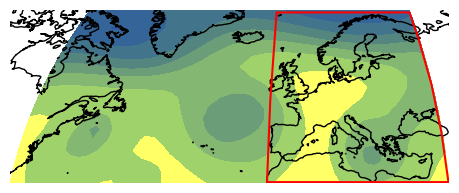

In [35]:
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

fig.set_figheight(2)


for spine in axis.spines.values():
    spine.set_visible(False)

ds_era5_circulation.sel(
    ensemble_member=similarities_era.ensemble_member,
    init_time=similarities_era.init_time,
    lead_time=similarities_era.lead_time,
)["geopotential_height"].plot.contourf(
    ax=axis,
    transform=ccrs.PlateCarree(),
    levels=all_levels,
    add_colorbar=False,
    cmap=cmap,
    norm=norm,
)
axis.coastlines()


"""add_contours(
    ax=axis,
    da=ds_era_circulation.sel(
        ensemble_member=similarities_era.ensemble_member,
        init_time=similarities_era.init_time,
        lead_time=similarities_era.lead_time,
    )["geopotential_height"],
    major_levels=major_levels,
    minor_levels=minor_levels,
    add_labels=True,
)"""

axis.plot(
    [
        ds_era5_impacts.longitude.min(),
        ds_era5_impacts.longitude.max(),
        ds_era5_impacts.longitude.max(),
        ds_era5_impacts.longitude.min(),
        ds_era5_impacts.longitude.min(),
    ],
    [
        ds_era5_impacts.latitude.min(),
        ds_era5_impacts.latitude.min(),
        ds_era5_impacts.latitude.max(),
        ds_era5_impacts.latitude.max(),
        ds_era5_impacts.latitude.min(),
    ],
    color="red",
    transform=ccrs.PlateCarree(),  # remove this line to get straight lines
)


axis.set_title("")
plt.tight_layout()
plt.savefig(os.path.join(paths["dir_images"], "illustrate_regions_geopotential.pdf"))

/tmp/ipykernel_1291629/481240814.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


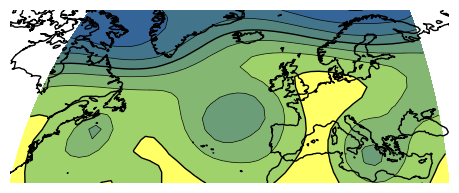

In [36]:
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

fig.set_figheight(2)

for spine in axis.spines.values():
    spine.set_visible(False)

ds_era5_circulation.sel(
    ensemble_member=similarities_era.ensemble_member,
    init_time=similarities_era.init_time,
    lead_time=similarities_era.lead_time,
)["geopotential_height"].plot.contourf(
    ax=axis,
    transform=ccrs.PlateCarree(),
    levels=all_levels,
    add_colorbar=False,
    cmap=cmap,
    norm=norm,
)
axis.coastlines()
add_contours(
    ax=axis,
    da=ds_era5_circulation.sel(
        ensemble_member=similarities_era.ensemble_member,
        init_time=similarities_era.init_time,
        lead_time=similarities_era.lead_time,
    )["geopotential_height"],
    major_levels=major_levels,
    minor_levels=minor_levels,
    use_contour_labels=False,
)
axis.set_title("")
plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "illustrate_neighbors_base.pdf"))

/tmp/ipykernel_1291629/2190267240.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/2190267240.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/2190267240.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/2190267240.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/2190267240.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


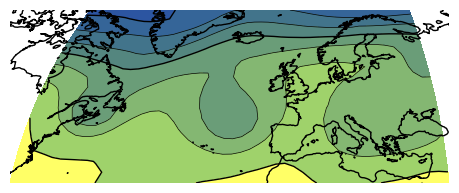

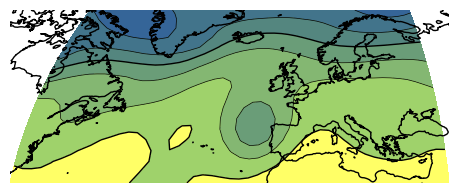

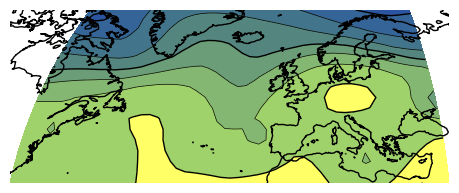

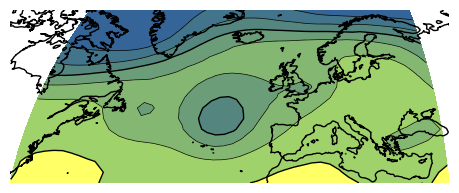

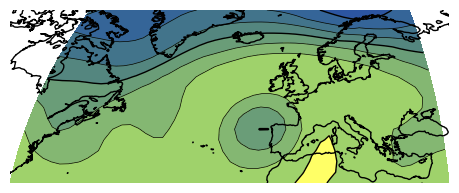

In [37]:
for i in range(5):
    da_nb = da_re.isel(neighbor=i)

    fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

    fig.set_figheight(2)

    for spine in axis.spines.values():
        spine.set_visible(False)

    da_nb.squeeze().plot.contourf(
        ax=axis,
        transform=ccrs.PlateCarree(),
        levels=all_levels,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    axis.coastlines()
    add_contours(
        ax=axis,
        da=da_nb.squeeze(),
        major_levels=major_levels,
        minor_levels=minor_levels,
        use_contour_labels=False,
    )
    axis.set_title("")
    plt.tight_layout()

    plt.savefig(os.path.join(paths["dir_images"], f"illustrate_neighbors_{i}.pdf"))

In [38]:
for i in range(k):
    da_nb = da_re.isel(neighbor=i)
    contourf_plot_without_frame_with_bounds(
        ax=ax_re,
        da=da_nb.squeeze(),
        levels=all_levels,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )

In [39]:
cmaps = {
    "t2m": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
        "cbar_kwargs": {"label": r"$T_{2m, mean}$ [°C]", "orientation": "horizontal"},
    },
    "mn2t": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
        "cbar_kwargs": {"label": r"$T_{2m, min}$ [°C]", "orientation": "horizontal"},
    },
    "mx2t": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
        "cbar_kwargs": {"label": r"$T_{2m, max}$ [°C]", "orientation": "horizontal"},
    },
    "tp": {
        "cmap": plt.get_cmap("cmc.lapaz_r"),
        "norm": mpl.colors.LogNorm(vmin=1, vmax=40),
        "cbar_kwargs": {"label": r"$tp$ [mm]", "orientation": "horizontal"},
    },
}

In [40]:
cmaps["tp"]["cmap"].set_bad("white")

/tmp/ipykernel_1291629/4010768143.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/4010768143.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/4010768143.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1291629/4010768143.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


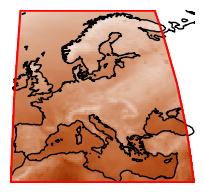

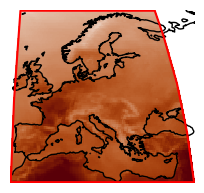

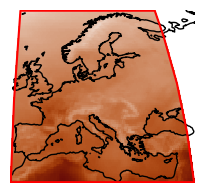

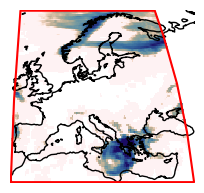

In [41]:
for var in ds_era5_impacts.data_vars:
    fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

    fig.set_figheight(2)

    for spine in axis.spines.values():
        spine.set_visible(False)

    ds_era5_impacts.sel(
        ensemble_member=similarities_era.ensemble_member,
        init_time=similarities_era.init_time,
        lead_time=similarities_era.lead_time,
    )[var].plot(
        ax=axis,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        cmap=cmaps[var]["cmap"],
        norm=cmaps[var]["norm"],
        rasterized=True,
    )
    axis.coastlines()

    axis.plot(
        [
            ds_era5_impacts.longitude.min(),
            ds_era5_impacts.longitude.max(),
            ds_era5_impacts.longitude.max(),
            ds_era5_impacts.longitude.min(),
            ds_era5_impacts.longitude.min(),
        ],
        [
            ds_era5_impacts.latitude.min(),
            ds_era5_impacts.latitude.min(),
            ds_era5_impacts.latitude.max(),
            ds_era5_impacts.latitude.max(),
            ds_era5_impacts.latitude.min(),
        ],
        color="red",
        transform=ccrs.PlateCarree(),  # remove this line to get straight lines
    )

    axis.set_title("")
    plt.tight_layout()
    plt.savefig(os.path.join(paths["dir_images"], f"illustrate_regions_{var}.pdf"))